In [1]:
import scanpy as sc

In [2]:
adata_rna = sc.read_h5ad("/Users/bdepouilly/CompBio/multiome-vae/data/processed/adata_rna_processed.h5ad")


In [3]:
import celltypist as ct

predictions = ct.annotate(adata_rna)
adata_rna.obs["cell_type"] = predictions.predicted_labels["predicted_labels"].values

/Users/bdepouilly/CompBio/multiome-vae/venv/lib/python3.14/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv
⚠️ Warning: invalid expression matrix, expect ALL genes and log1p normalized expression to 10000 counts per cell. The prediction result may not be accurate
🔬 Input data has 7482 cells and 5000 genes
🔗 Matching reference genes in the model
🧬 1556 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!


In [4]:
sc.tl.pca(adata_rna)

In [5]:
adata_rna

AnnData object with n_obs × n_vars = 7482 × 5000
    obs: 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'outlier', 'mt_outlier', 'cell_type'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts'

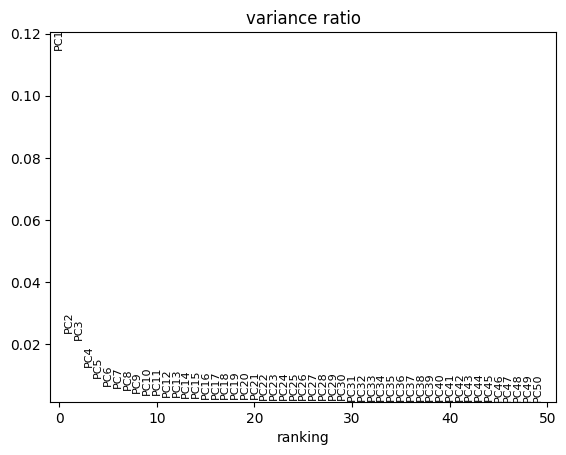

In [6]:
sc.pl.pca_variance_ratio(adata_rna, n_pcs=50)

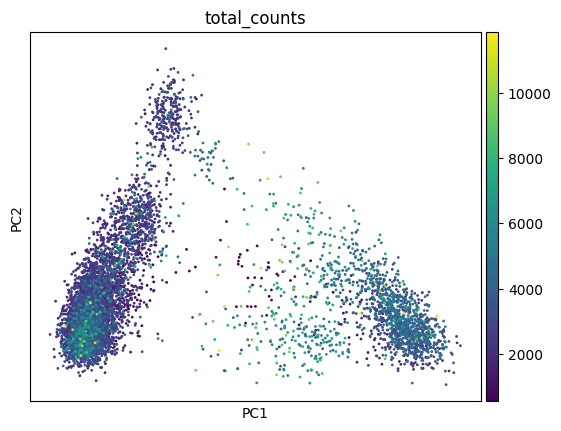

In [7]:
sc.pl.pca(adata_rna, color="total_counts")

In [8]:
sc.pp.neighbors(adata_rna)

/Users/bdepouilly/CompBio/multiome-vae/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
sc.tl.umap(adata_rna)

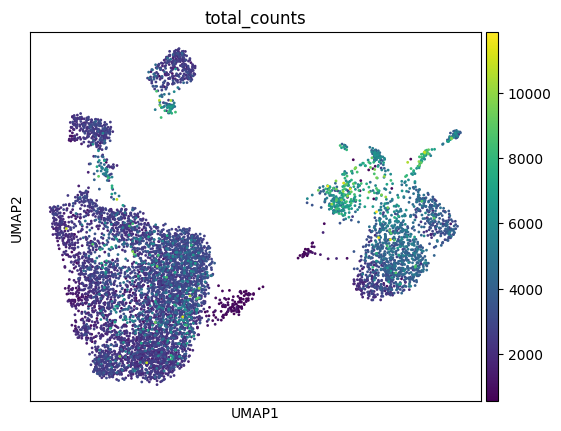

In [10]:
sc.pl.umap(adata_rna, color="total_counts")

In [16]:
sorted(adata_rna.obs["cell_type"].unique())

['Age-associated B cells',
 'Alveolar macrophages',
 'CD16+ NK cells',
 'CD16- NK cells',
 'CD8a/a',
 'CMP',
 'CRTAM+ gamma-delta T cells',
 'Classical monocytes',
 'Cycling B cells',
 'Cycling DCs',
 'Cycling T cells',
 'DC',
 'DC1',
 'DC2',
 'DC3',
 'Double-negative thymocytes',
 'Double-positive thymocytes',
 'ETP',
 'Early MK',
 'Endothelial cells',
 'Epithelial cells',
 'Fibroblasts',
 'Follicular helper T cells',
 'GMP',
 'Granulocytes',
 'ILC1',
 'ILC3',
 'Intermediate macrophages',
 'Kupffer cells',
 'Late erythroid',
 'MAIT cells',
 'Macrophages',
 'Mast cells',
 'Megakaryocyte precursor',
 'Megakaryocytes/platelets',
 'Memory B cells',
 'Memory CD4+ cytotoxic T cells',
 'Mid erythroid',
 'Monocyte precursor',
 'NK cells',
 'Naive B cells',
 'Non-classical monocytes',
 'Plasma cells',
 'Regulatory T cells',
 'T(agonist)',
 'Tcm/Naive cytotoxic T cells',
 'Tcm/Naive helper T cells',
 'Tem/Effector helper T cells',
 'Tem/Effector helper T cells PD1+',
 'Tem/Temra cytotoxic T cel

In [19]:
coarse_map = {
    "Memory B cells" : "B cells",
    "Tcm/Naive cytotoxic T cells" : "T cells",
    "Tcm/Naive helper T cells" : "T cells",
    "Tem/Effector helper T cells" : "T cells",
    "Tem/Trm cytotoxic T cells" : "T cells",
    "CD16+ NK cells" : "NK cells",
    "Regulatory T cells" : "T cells",
    "Tem/Temra cytotoxic T cells" : "T cells",
    "Naive B cells" : "B cells",
    "Non-classical monocytes" : "Monocytes",
    "CD16- NK cells" : "NK cells",
    "Age-associated B cells" : "B cells",
    "NK cells" : "NK cells",
    "Tem/Effector helper T cells PD1+" : "T cells",
    "CRTAM+ gamma-delta T cells" : "T cells",
    "Trm cytotoxic T cells" : "T cells",
    "Cycling T cells" : "T cells",
    "Memory CD4+ cytotoxic T cells" : "T cells",
    "Type 17 helper T cells" : "T cells",
    "Cycling B cells" : "B cells",
    "Plasma cells" : "B cells",
    "Follicular helper T cells" : "T cells",
    "DC" : "Dendritic cells",
    "DC1" : "Dendritic cells",
    "DC2" : "Dendritic cells",
    "DC3" : "Dendritic cells",
}

adata_rna.obs["cell_type_coarse"] = adata_rna.obs["cell_type"].map(coarse_map).fillna("Other")

... storing 'cell_type_coarse' as categorical


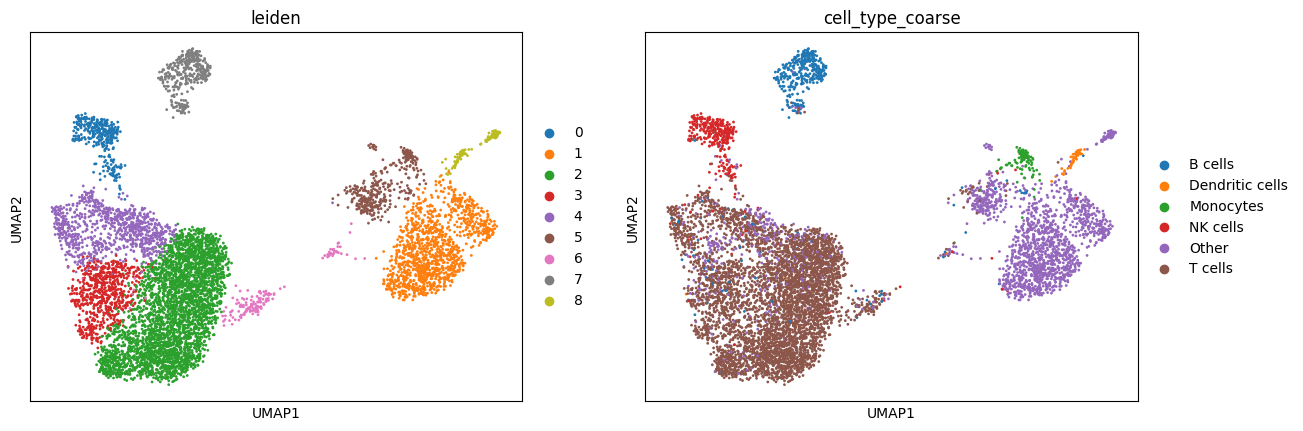

In [20]:
sc.tl.leiden(adata_rna, resolution=0.4, flavor="igraph", n_iterations=2)
sc.pl.umap(adata_rna, color=["leiden", "cell_type_coarse"])